In [33]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 43.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [catboost]1/2 [catboost]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [107]:
!pip install optuna

  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.032m0/5 [typing-extensions]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [optuna]2m4/5 [optuna]]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Train shape : (8523, 12)
Test shape  : (5681, 11)

Missing in Train:
Outlet_Size    2410
Item_Weight    1463
dtype: int64

Missing in Test:
Outlet_Size    1606
Item_Weight     976
dtype: int64

EDA


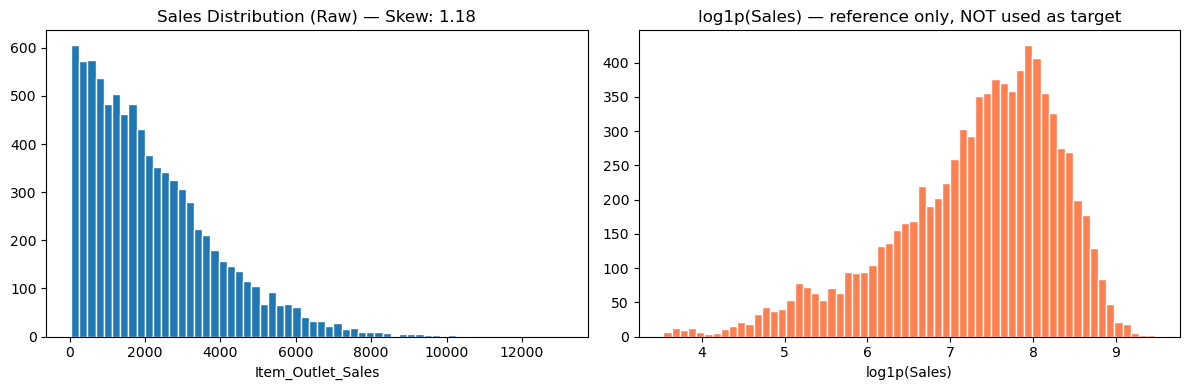

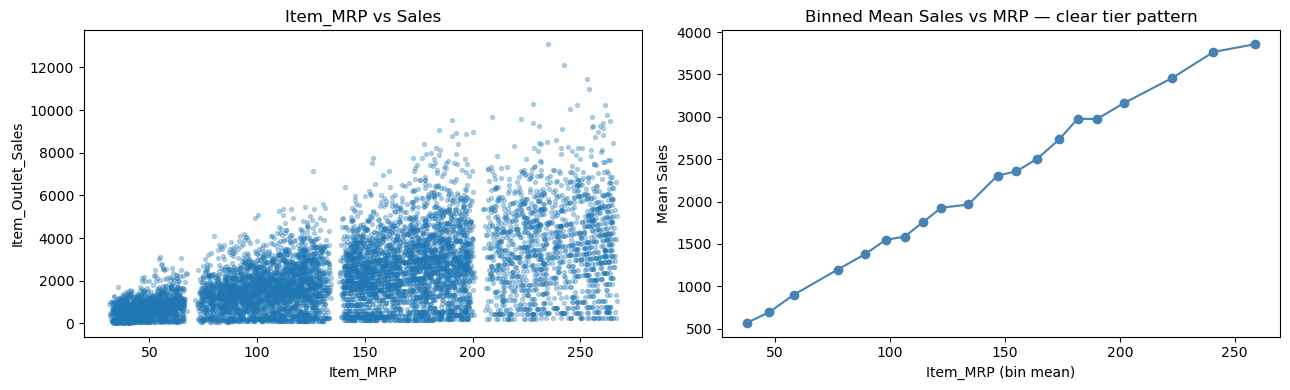

MRP–Sales corr (raw): 0.5676
MRP²–Sales corr     : 0.5519


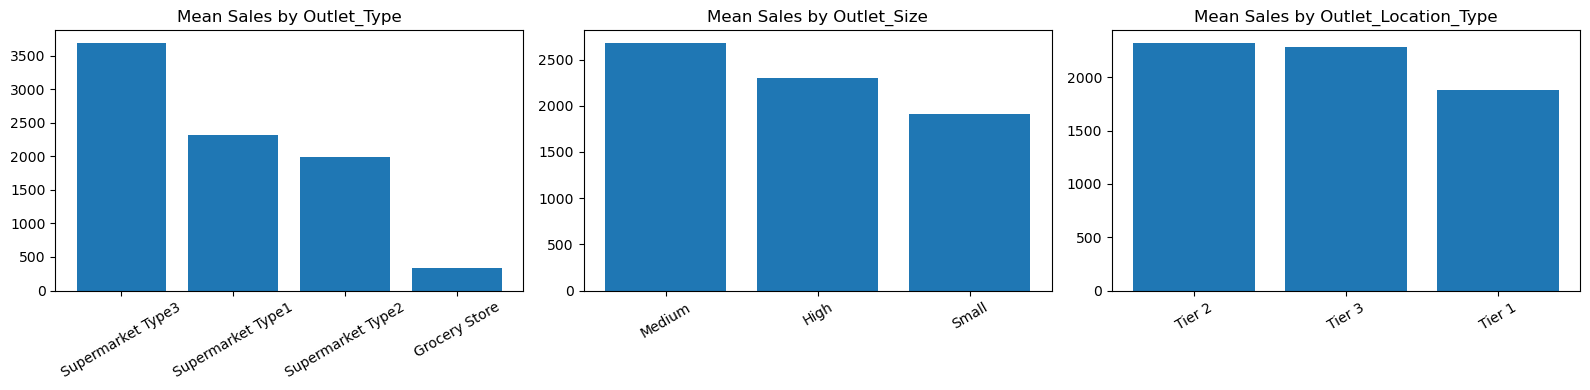


Mean Sales by Outlet_Type:
 Outlet_Type
Grocery Store         340.0
Supermarket Type1    2316.0
Supermarket Type2    1995.0
Supermarket Type3    3694.0
Name: Item_Outlet_Sales, dtype: float64

Mean Sales by Outlet_Identifier:
 Outlet_Identifier
OUT027    3694.0
OUT035    2439.0
OUT049    2348.0
OUT017    2341.0
OUT013    2299.0
OUT046    2278.0
OUT045    2192.0
OUT018    1995.0
OUT019     340.0
OUT010     339.0
Name: Item_Outlet_Sales, dtype: float64


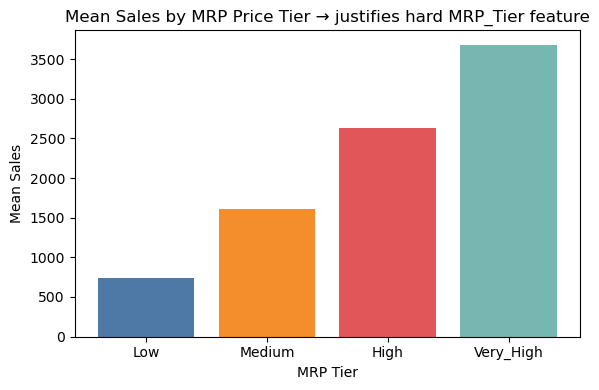


Mean Sales by MRP Tier:
 Item_MRP
Low           736.0
Medium       1616.0
High         2631.0
Very_High    3681.0
Name: Item_Outlet_Sales, dtype: float64


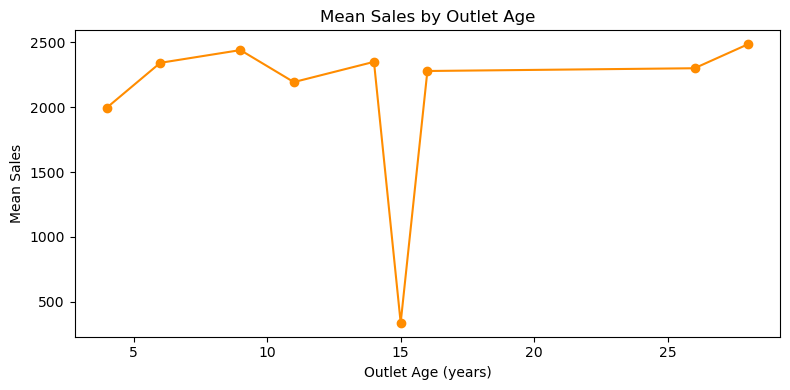

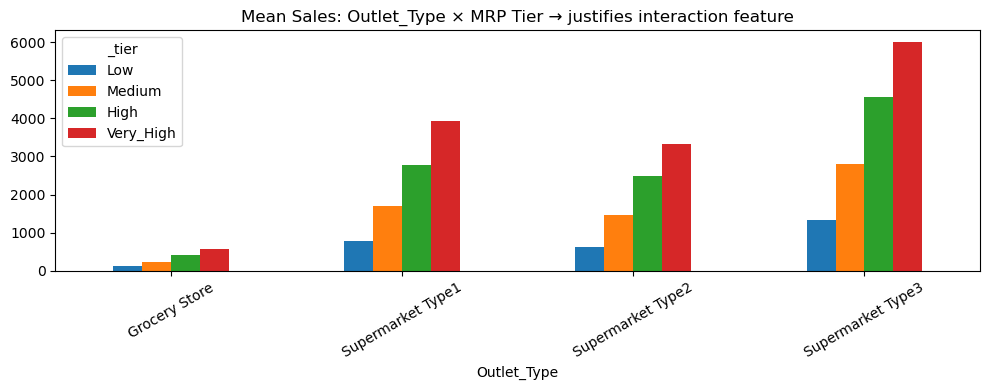

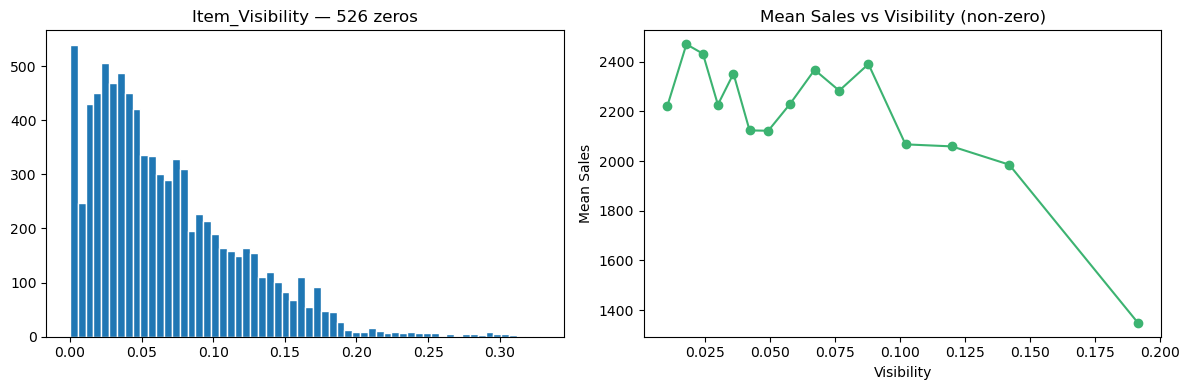


Mean Sales — Grocery vs Others:
Outlet_Type
Grocery Store     340.0
Other Outlets    2449.0
Name: Item_Outlet_Sales, dtype: float64

MRP²–Sales corr vs MRP–Sales corr:
  MRP  corr: 0.5676
  MRP² corr: 0.5519

PREPROCESSING
Outlet_Size missing : 0
Item_Weight missing : 0
Visibility zeros    : 0

FEATURE ENGINEERING
Feature engineering complete. Total columns: 52

PREPARING MODEL INPUTS
Total features   : 49
Numeric features : 37
Categorical feats: 12
Cat feature list : ['Outlet_Identifier', 'Item_Identifier', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Size', 'Item_Type', 'Item_Fat_Content', 'Item_Category', 'Outlet_Age_Bin', 'MRP_Tier', 'ItemCat_x_OutletType', 'MRPTier_x_OutletType']

Target — mean=2181.3, std=1706.4, min=33.3, max=13087.0
No missing values ✅

OPTUNA HYPERPARAMETER TUNING (50 trials)
This will take ~20-30 minutes. Get a coffee ☕


  0%|          | 0/50 [00:00<?, ?it/s]


OPTUNA RESULTS
Best CV RMSE : 1075.54
Best params  :
  learning_rate            : 0.0730898320997538
  depth                    : 8
  l2_leaf_reg              : 5.367317844572137
  subsample                : 0.6595452735770221
  colsample_bylevel        : 0.868704167373366
  min_data_in_leaf         : 4
  bagging_temperature      : 0.8506171326413019


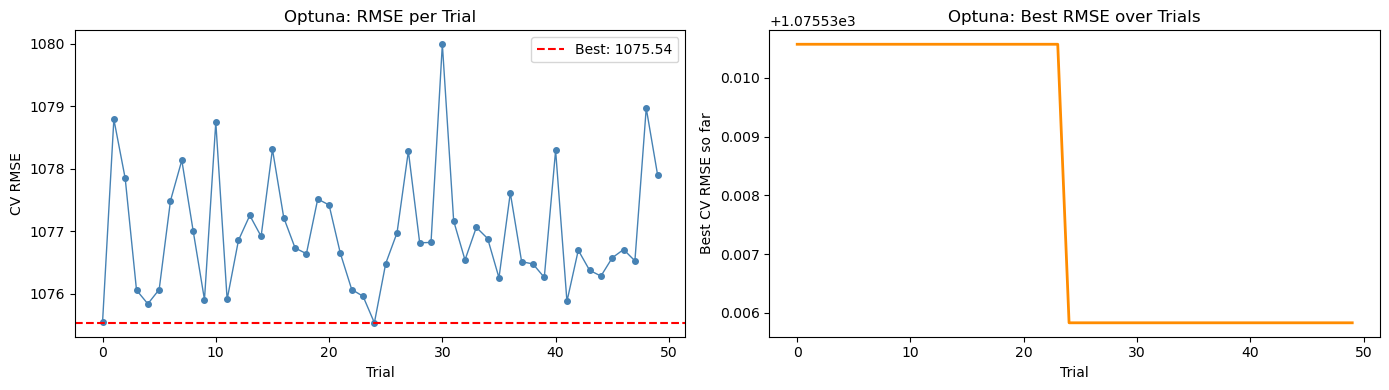


CATBOOST TRAINING WITH BEST PARAMS (RAW SALES)

Final training params:
  loss_function            : RMSE
  eval_metric              : RMSE
  iterations               : 5000
  learning_rate            : 0.0730898320997538
  depth                    : 8
  l2_leaf_reg              : 5.367317844572137
  subsample                : 0.6595452735770221
  colsample_bylevel        : 0.868704167373366
  min_data_in_leaf         : 4
  bagging_temperature      : 0.8506171326413019
  random_seed              : 42
  od_type                  : Iter
  od_wait                  : 200
  verbose                  : 200
  allow_writing_files      : False
0:	learn: 1651.1088573	test: 1580.9234173	best: 1580.9234173 (0)	total: 22.8ms	remaining: 1m 53s
200:	learn: 992.7497687	test: 1020.5204479	best: 1016.1470622 (77)	total: 4.35s	remaining: 1m 43s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1016.147062
bestIteration = 77

Shrink model to first 78 iterations.

  ✅ Fold 1: RMSE = 1016.15 

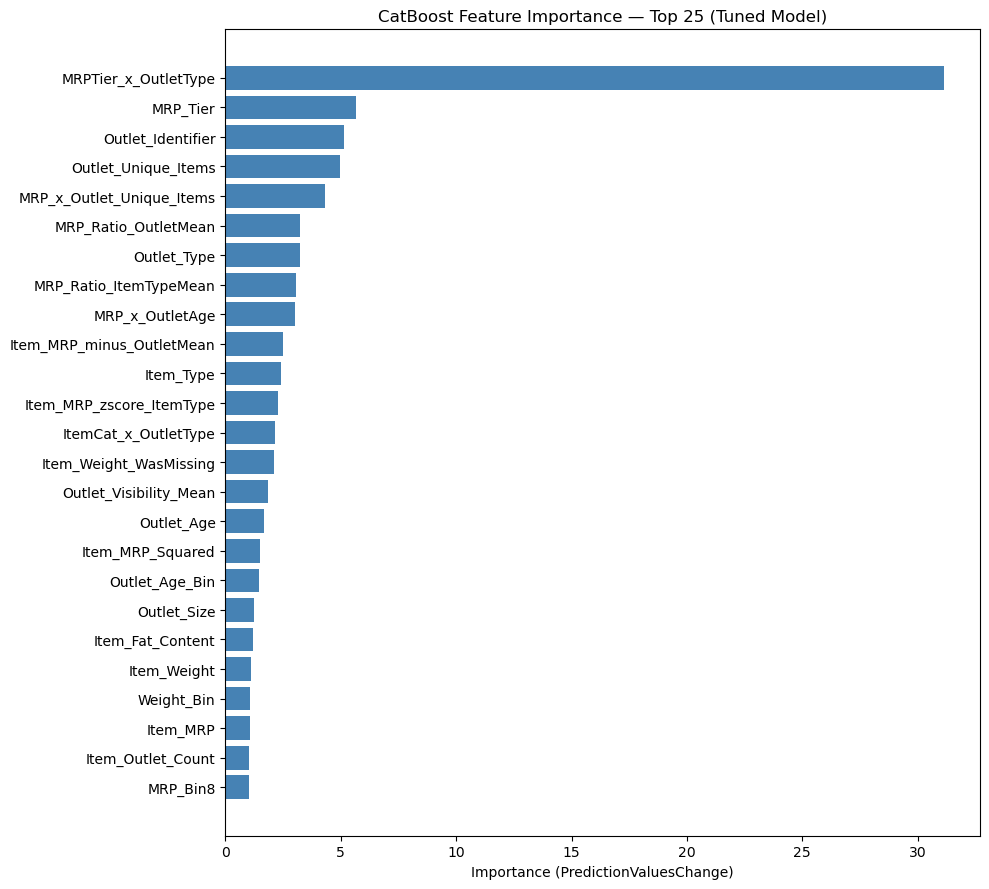


OOF PREDICTION ANALYSIS
OOF RMSE (all folds combined): 1076.11


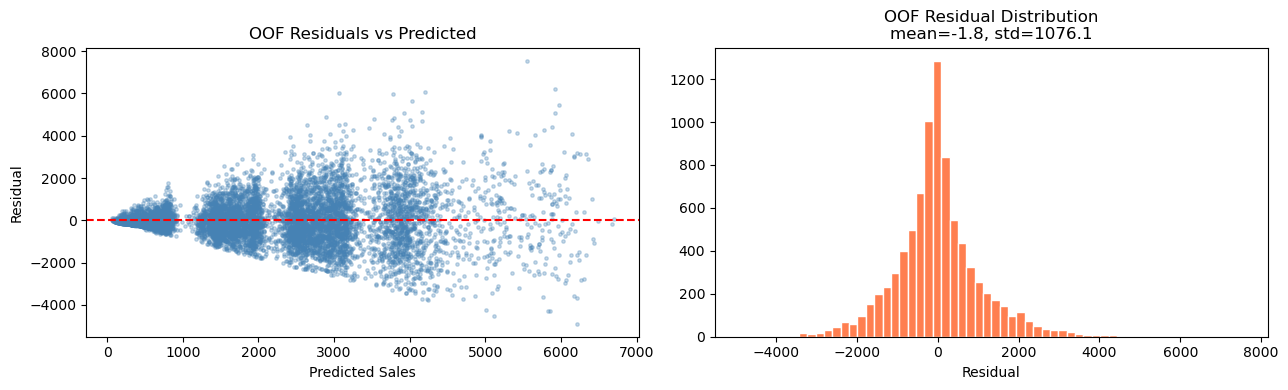


CREATING SUBMISSION FILE
  ✅ Submission saved : /Users/bujji/Documents/Mumbai/Case_analytics_vidhya_ABB/submission_CatBoost_optuna.csv
  Shape              : (5681, 3)
  Negative values    : 0 (clipped to 33.29)
  Prediction stats   :
    mean = 2182.6
    std  = 1317.1
    min  = 87.2
    max  = 6322.1

Item_Identifier Outlet_Identifier  Item_Outlet_Sales
          FDW58            OUT049        1690.128351
          FDW14            OUT017        1458.170219
          NCN55            OUT010         690.358107
          FDQ58            OUT017        2585.289586
          FDY38            OUT027        5951.929205
          FDH56            OUT046        1902.649436
          FDL48            OUT018         649.313012
          FDC48            OUT027        2370.531059
          FDN33            OUT045        1558.448987
          FDA36            OUT017        3123.452919

FINAL SUMMARY
 Fold    RMSE  Best_Iter
    1 1016.15         77
    2 1071.99        244
    3 1065.42       

In [108]:
# ============================================================
# BIGMART SALES PREDICTION — OPTUNA TUNED PIPELINE
# ============================================================
# Strategy:
#   - All Cell-13 features (gave 1150)
#   - 6 new features on top
#   - RAW sales target (no log transform)
#   - Optuna hyperparameter tuning (50 trials)
#   - CatBoost only with best params
#   - Negative prediction clip to prevent portal rejection
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
SALES_YEAR  = 2013
N_FOLDS     = 5

# ============================================================
# 1) LOAD DATA
# ============================================================

train_path = "/Users/bujji/Documents/Mumbai/Case_analytics_vidhya_ABB/train_v9rqX0R.csv"
test_path  = "/Users/bujji/Documents/Mumbai/Case_analytics_vidhya_ABB/test_AbJTz2l.csv"

train_raw = pd.read_csv(train_path)
test_raw  = pd.read_csv(test_path)

print(f"Train shape : {train_raw.shape}")
print(f"Test shape  : {test_raw.shape}")
print(f"\nMissing in Train:\n{train_raw.isna().sum()[train_raw.isna().sum() > 0]}")
print(f"\nMissing in Test:\n{test_raw.isna().sum()[test_raw.isna().sum() > 0]}")

# ============================================================
# 2) EDA — key plots
# ============================================================
print("\n" + "="*60)
print("EDA")
print("="*60)

# ---- 2.1 Target distribution ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_raw["Item_Outlet_Sales"], bins=60, edgecolor="white")
axes[0].set_title("Sales Distribution (Raw) — Skew: {:.2f}".format(
    train_raw["Item_Outlet_Sales"].skew()))
axes[0].set_xlabel("Item_Outlet_Sales")
axes[1].hist(np.log1p(train_raw["Item_Outlet_Sales"]),
             bins=60, edgecolor="white", color="coral")
axes[1].set_title("log1p(Sales) — reference only, NOT used as target")
axes[1].set_xlabel("log1p(Sales)")
plt.tight_layout(); plt.show()

# ---- 2.2 MRP vs Sales ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(train_raw["Item_MRP"], train_raw["Item_Outlet_Sales"],
                s=8, alpha=0.3)
axes[0].set_title("Item_MRP vs Sales")
axes[0].set_xlabel("Item_MRP"); axes[0].set_ylabel("Item_Outlet_Sales")
tmp = train_raw.copy()
tmp["mrp_bin"] = pd.qcut(tmp["Item_MRP"], q=20, duplicates="drop")
binned = tmp.groupby("mrp_bin", observed=True).agg(
    mrp_mean=("Item_MRP","mean"), sales_mean=("Item_Outlet_Sales","mean"))
axes[1].plot(binned["mrp_mean"], binned["sales_mean"],
             marker="o", color="steelblue")
axes[1].set_title("Binned Mean Sales vs MRP — clear tier pattern")
axes[1].set_xlabel("Item_MRP (bin mean)"); axes[1].set_ylabel("Mean Sales")
plt.tight_layout(); plt.show()
print("MRP–Sales corr (raw):", round(
    train_raw["Item_MRP"].corr(train_raw["Item_Outlet_Sales"]), 4))
print("MRP²–Sales corr     :", round(
    (train_raw["Item_MRP"]**2).corr(train_raw["Item_Outlet_Sales"]), 4))

# ---- 2.3 Sales by categorical drivers ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Outlet_Type","Outlet_Size","Outlet_Location_Type"]):
    g = (train_raw.groupby(col)["Item_Outlet_Sales"]
                  .mean().sort_values(ascending=False))
    ax.bar(g.index.astype(str), g.values)
    ax.set_title(f"Mean Sales by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
print("\nMean Sales by Outlet_Type:\n",
      train_raw.groupby("Outlet_Type")["Item_Outlet_Sales"].mean().round(0))
print("\nMean Sales by Outlet_Identifier:\n",
      train_raw.groupby("Outlet_Identifier")["Item_Outlet_Sales"]
               .mean().sort_values(ascending=False).round(0))

# ---- 2.4 MRP Hard Tier Evidence ----
tier_labels = pd.cut(train_raw["Item_MRP"], bins=[0,69,136,202,270],
                     labels=["Low","Medium","High","Very_High"])
tier_sales  = train_raw.groupby(
    tier_labels, observed=True)["Item_Outlet_Sales"].mean()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(tier_sales.index.astype(str), tier_sales.values,
       color=["#4e79a7","#f28e2b","#e15759","#76b7b2"])
ax.set_title("Mean Sales by MRP Price Tier → justifies hard MRP_Tier feature")
ax.set_xlabel("MRP Tier"); ax.set_ylabel("Mean Sales")
plt.tight_layout(); plt.show()
print("\nMean Sales by MRP Tier:\n", tier_sales.round(0))

# ---- 2.5 Outlet Age vs Sales ----
train_raw["_age"] = SALES_YEAR - train_raw["Outlet_Establishment_Year"]
age_sales = train_raw.groupby("_age")["Item_Outlet_Sales"].mean()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(age_sales.index, age_sales.values, marker="o", color="darkorange")
ax.set_title("Mean Sales by Outlet Age")
ax.set_xlabel("Outlet Age (years)"); ax.set_ylabel("Mean Sales")
plt.tight_layout(); plt.show()

# ---- 2.6 Outlet_Type × MRP_Tier interaction ----
train_raw["_tier"] = pd.cut(train_raw["Item_MRP"], bins=[0,69,136,202,270],
                             labels=["Low","Medium","High","Very_High"])
pivot = train_raw.groupby(
    ["Outlet_Type","_tier"], observed=True)["Item_Outlet_Sales"].mean().unstack()
fig, ax = plt.subplots(figsize=(10, 4))
pivot.plot(kind="bar", ax=ax)
ax.set_title("Mean Sales: Outlet_Type × MRP Tier → justifies interaction feature")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

# ---- 2.7 Visibility analysis ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_raw["Item_Visibility"], bins=60, edgecolor="white")
axes[0].set_title(f"Item_Visibility — "
                  f"{(train_raw['Item_Visibility']==0).sum()} zeros")
vis_nz = train_raw[train_raw["Item_Visibility"] > 0].copy()
vis_nz["vis_bin"] = pd.qcut(vis_nz["Item_Visibility"], q=15, duplicates="drop")
vb = vis_nz.groupby("vis_bin", observed=True).agg(
    v_mean=("Item_Visibility","mean"), s_mean=("Item_Outlet_Sales","mean"))
axes[1].plot(vb["v_mean"], vb["s_mean"], marker="o", color="mediumseagreen")
axes[1].set_title("Mean Sales vs Visibility (non-zero)")
axes[1].set_xlabel("Visibility"); axes[1].set_ylabel("Mean Sales")
plt.tight_layout(); plt.show()

# ---- 2.8 Grocery Store effect ----
print("\nMean Sales — Grocery vs Others:")
print(train_raw.groupby(
    train_raw["Outlet_Type"].eq("Grocery Store")
               .map({True:"Grocery Store", False:"Other Outlets"})
)["Item_Outlet_Sales"].mean().round(0))

# ---- 2.9 MRP Squared vs Sales ----
print("\nMRP²–Sales corr vs MRP–Sales corr:")
print(f"  MRP  corr: {train_raw['Item_MRP'].corr(train_raw['Item_Outlet_Sales']):.4f}")
print(f"  MRP² corr: {(train_raw['Item_MRP']**2).corr(train_raw['Item_Outlet_Sales']):.4f}")

# cleanup
train_raw.drop(columns=["_age","_tier"], inplace=True, errors="ignore")

# ============================================================
# 3) PREPROCESSING — combine train + test
# ============================================================
print("\n" + "="*60)
print("PREPROCESSING")
print("="*60)

train_raw["_is_train"] = 1
test_raw["_is_train"]  = 0
full_df = pd.concat([train_raw, test_raw], axis=0, ignore_index=True)

# ---- 3.1 Normalize Fat Content ----
fat_map = {
    "low fat":"Low Fat", "lf":"Low Fat",     "LF":"Low Fat",
    "reg":"Regular",     "regular":"Regular", "Regular ":"Regular"
}
full_df["Item_Fat_Content"] = (
    full_df["Item_Fat_Content"].astype(str).str.strip().replace(fat_map)
)

# ---- 3.2 Item Category from prefix ----
full_df["Item_Category"] = full_df["Item_Identifier"].str[:2].map(
    {"FD":"Food","DR":"Drinks","NC":"Non-Consumable"}
).fillna("Unknown")
full_df.loc[full_df["Item_Category"] == "Non-Consumable",
            "Item_Fat_Content"] = "Non-Edible"

# ---- 3.3 Missing flags ----
full_df["Outlet_Size_WasMissing"] = full_df["Outlet_Size"].isna().astype(int)
full_df["Item_Weight_WasMissing"] = full_df["Item_Weight"].isna().astype(int)
full_df["Visibility_WasZero"]     = (full_df["Item_Visibility"] == 0).astype(int)

# ---- 3.4 Outlet_Size imputation (3-tier fallback) ----
outlet_size_map = (
    full_df.dropna(subset=["Outlet_Size"])
           .groupby("Outlet_Identifier")["Outlet_Size"]
           .agg(lambda s: s.mode().iloc[0])
)
full_df["Outlet_Size"] = full_df["Outlet_Size"].fillna(
    full_df["Outlet_Identifier"].map(outlet_size_map))
type_loc_mode = (
    full_df.dropna(subset=["Outlet_Size"])
           .groupby(["Outlet_Type","Outlet_Location_Type"])["Outlet_Size"]
           .agg(lambda s: s.mode().iloc[0])
)
mask = full_df["Outlet_Size"].isna()
full_df.loc[mask, "Outlet_Size"] = (
    full_df.loc[mask, ["Outlet_Type","Outlet_Location_Type"]]
           .apply(lambda r: type_loc_mode.get(
               (r["Outlet_Type"], r["Outlet_Location_Type"]), np.nan), axis=1)
)
full_df["Outlet_Size"] = full_df["Outlet_Size"].fillna(
    full_df["Outlet_Size"].mode().iloc[0])
print(f"Outlet_Size missing : {full_df['Outlet_Size'].isna().sum()}")

# ---- 3.5 Item_Weight imputation ----
item_weight_map = (
    full_df.dropna(subset=["Item_Weight"])
           .groupby("Item_Identifier")["Item_Weight"].median()
)
full_df["Item_Weight"] = full_df["Item_Weight"].fillna(
    full_df["Item_Identifier"].map(item_weight_map))
itemtype_weight_median = (
    full_df.dropna(subset=["Item_Weight"])
           .groupby("Item_Type")["Item_Weight"].median()
)
mask = full_df["Item_Weight"].isna()
full_df.loc[mask, "Item_Weight"] = (
    full_df.loc[mask, "Item_Type"].map(itemtype_weight_median))
full_df["Item_Weight"] = full_df["Item_Weight"].fillna(
    full_df["Item_Weight"].median())
print(f"Item_Weight missing : {full_df['Item_Weight'].isna().sum()}")

# ---- 3.6 Visibility zero imputation (SKU-level) ----
item_vis_map = (
    full_df[full_df["Item_Visibility"] > 0]
           .groupby("Item_Identifier")["Item_Visibility"].median()
)
mask_zero = (full_df["Item_Visibility"] == 0)
full_df.loc[mask_zero, "Item_Visibility"] = (
    full_df.loc[mask_zero, "Item_Identifier"].map(item_vis_map))
itemtype_vis_median = (
    full_df[full_df["Item_Visibility"] > 0]
           .groupby("Item_Type")["Item_Visibility"].median()
)
mask_still = full_df["Item_Visibility"].isna() | (full_df["Item_Visibility"] == 0)
full_df.loc[mask_still, "Item_Visibility"] = (
    full_df.loc[mask_still, "Item_Type"].map(itemtype_vis_median))
full_df["Item_Visibility"] = full_df["Item_Visibility"].fillna(
    full_df["Item_Visibility"].median())
print(f"Visibility zeros    : {(full_df['Item_Visibility'] == 0).sum()}")

# ============================================================
# 4) FEATURE ENGINEERING
# ============================================================
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# ================================================================
# (A) ORIGINAL CELL-13 FEATURES — baseline that gave 1150 RMSE
# ================================================================

# Outlet Age
full_df["Outlet_Age"] = SALES_YEAR - full_df["Outlet_Establishment_Year"]

# MRP bins (soft)
full_df["MRP_Bin"]  = pd.qcut(full_df["Item_MRP"], q=4, labels=False,
                               duplicates="drop").astype(float)
full_df["MRP_Bin8"] = pd.qcut(full_df["Item_MRP"], q=8, labels=False,
                               duplicates="drop").astype(float)

# Relative MRP within item type
itemtype_mrp_mean = full_df.groupby("Item_Type")["Item_MRP"].transform("mean")
itemtype_mrp_std  = full_df.groupby("Item_Type")["Item_MRP"].transform("std").replace(0,1)
full_df["MRP_Ratio_ItemTypeMean"]   = full_df["Item_MRP"] / itemtype_mrp_mean
full_df["Item_MRP_zscore_ItemType"] = (full_df["Item_MRP"] - itemtype_mrp_mean) / itemtype_mrp_std
full_df["MRP_RankPct_ItemType"]     = (
    full_df.groupby("Item_Type")["Item_MRP"].transform(lambda x: x.rank(pct=True))
)

# Relative MRP within outlet
outlet_mrp_mean = full_df.groupby("Outlet_Identifier")["Item_MRP"].transform("mean")
outlet_mrp_std  = full_df.groupby("Outlet_Identifier")["Item_MRP"].transform("std").replace(0,1)
full_df["MRP_Ratio_OutletMean"]      = full_df["Item_MRP"] / outlet_mrp_mean
full_df["Item_MRP_minus_OutletMean"] = full_df["Item_MRP"] - outlet_mrp_mean
full_df["Outlet_MRP_Mean"]           = outlet_mrp_mean
full_df["Outlet_MRP_Std"]            = outlet_mrp_std

# Visibility features
full_df["Item_Visibility_log1p"]  = np.log1p(full_df["Item_Visibility"])
vis_cap = full_df["Item_Visibility"].quantile(0.95)
full_df["Item_Visibility_capped"] = full_df["Item_Visibility"].clip(upper=vis_cap)

itemtype_vis_mean  = full_df.groupby("Item_Type")["Item_Visibility"].transform("mean")
outlet_vis_mean    = full_df.groupby("Outlet_Identifier")["Item_Visibility"].transform("mean")
full_df["Visibility_Ratio_ItemTypeMean"]    = full_df["Item_Visibility"] / itemtype_vis_mean
full_df["Visibility_Ratio_OutletMean"]      = full_df["Item_Visibility"] / outlet_vis_mean
full_df["Item_Visibility_minus_OutletMean"] = full_df["Item_Visibility"] - outlet_vis_mean
full_df["Outlet_Visibility_Mean"]           = outlet_vis_mean
full_df["Item_Visibility_per_Weight"]       = (
    full_df["Item_Visibility"] / (full_df["Item_Weight"] + 1e-6))

# Weight features
itemtype_weight_mean = full_df.groupby("Item_Type")["Item_Weight"].transform("mean")
itemtype_weight_std  = full_df.groupby("Item_Type")["Item_Weight"].transform("std").replace(0,1)
full_df["Item_Weight_zscore_ItemType"] = (
    (full_df["Item_Weight"] - itemtype_weight_mean) / itemtype_weight_std)

# Outlet assortment breadth
full_df["Outlet_Unique_Items"]     = (
    full_df.groupby("Outlet_Identifier")["Item_Identifier"].transform("nunique"))
full_df["Outlet_Unique_ItemTypes"] = (
    full_df.groupby("Outlet_Identifier")["Item_Type"].transform("nunique"))
full_df["Outlet_Item_Count"]       = (
    full_df.groupby("Outlet_Identifier")["Item_Identifier"].transform("count"))
full_df["Item_Outlet_Count"]       = (
    full_df.groupby("Item_Identifier")["Outlet_Identifier"].transform("count"))

# Interaction features
full_df["MRP_x_OutletAge"]           = full_df["Item_MRP"] * full_df["Outlet_Age"]
full_df["Visibility_x_MRP"]          = full_df["Item_Visibility"] * full_df["Item_MRP"]
full_df["MRP_x_Outlet_Unique_Items"] = full_df["Item_MRP"] * full_df["Outlet_Unique_Items"]
full_df["Visibility_x_Outlet_Age"]   = full_df["Item_Visibility"] * full_df["Outlet_Age"]

# Bin features
full_df["Weight_Bin"] = pd.qcut(full_df["Item_Weight"], q=5, labels=False,
                                  duplicates="drop").astype(float)
full_df["Outlet_Age_Bin"] = pd.cut(
    full_df["Outlet_Age"],
    bins=[0,5,10,15,20,100],
    labels=["0-5","5-10","10-15","15-20","20+"]
).astype(str)

# ================================================================
# (B) NEW FEATURES — incremental improvements over Cell-13 baseline
# ================================================================

# 1) MRP Hard Tier — step-function breakpoints confirmed by EDA
full_df["MRP_Tier"] = pd.cut(
    full_df["Item_MRP"],
    bins=[0, 69, 136, 202, 1000],
    labels=["Low","Medium","High","Very_High"]
).astype(str)

# 2) MRP Squared — captures super-linear price-sales relationship
full_df["Item_MRP_Squared"] = full_df["Item_MRP"] ** 2

# 3) Grocery Store flag — OUT010, OUT019 mean sales ~340 vs ~2300 others
full_df["Is_Grocery_Store"] = (
    full_df["Outlet_Type"] == "Grocery Store").astype(int)

# 4) MRP × Grocery — price behaves completely differently in grocery stores
full_df["MRP_x_Is_Grocery"] = full_df["Item_MRP"] * full_df["Is_Grocery_Store"]

# 5) Visibility outlet share — item's shelf fraction within its own store
outlet_total_vis = full_df.groupby(
    "Outlet_Identifier")["Item_Visibility"].transform("sum")
full_df["Visibility_OutletShare"] = full_df["Item_Visibility"] / outlet_total_vis

# 6) String interaction cat features — CatBoost handles these natively
full_df["ItemCat_x_OutletType"]  = (
    full_df["Item_Category"].astype(str) + "_" + full_df["Outlet_Type"].astype(str))
full_df["MRPTier_x_OutletType"]  = (
    full_df["MRP_Tier"].astype(str) + "_" + full_df["Outlet_Type"].astype(str))

print(f"Feature engineering complete. Total columns: {full_df.shape[1]}")

# ============================================================
# 5) SPLIT BACK + PREPARE MODEL INPUTS
# ============================================================
print("\n" + "="*60)
print("PREPARING MODEL INPUTS")
print("="*60)

train_mask = full_df["_is_train"] == 1
test_mask  = full_df["_is_train"] == 0

processed_train = full_df[train_mask].copy()
processed_test  = full_df[test_mask].copy()

# RAW sales target — no log transform
y = processed_train["Item_Outlet_Sales"].values.astype(float)

drop_cols = [
    "Item_Outlet_Sales",
    "_is_train",
    "Outlet_Establishment_Year",   # replaced by Outlet_Age
]
X      = processed_train.drop(
    columns=[c for c in drop_cols if c in processed_train.columns])
X_test = processed_test[X.columns].copy()

# String/object columns → CatBoost native categorical handling
cat_features_cb = X.select_dtypes(include=["object","category"]).columns.tolist()

print(f"Total features   : {X.shape[1]}")
print(f"Numeric features : {X.select_dtypes(include=['int64','float64']).shape[1]}")
print(f"Categorical feats: {len(cat_features_cb)}")
print(f"Cat feature list : {cat_features_cb}")
print(f"\nTarget — mean={y.mean():.1f}, std={y.std():.1f}, "
      f"min={y.min():.1f}, max={y.max():.1f}")

assert X.isna().sum().sum() == 0,     "NaN in X!"
assert X_test.isna().sum().sum() == 0, "NaN in X_test!"
print("No missing values ✅")

# ============================================================
# 6) OPTUNA HYPERPARAMETER TUNING
# ============================================================
print("\n" + "="*60)
print("OPTUNA HYPERPARAMETER TUNING (50 trials)")
print("This will take ~20-30 minutes. Get a coffee ☕")
print("="*60)

def objective(trial):
    params = {
        "loss_function"    : "RMSE",
        "eval_metric"      : "RMSE",
        "iterations"       : 3000,
        "learning_rate"    : trial.suggest_float("learning_rate",   0.03,  0.15, log=True),
        "depth"            : trial.suggest_int(  "depth",            6,     10),
        "l2_leaf_reg"      : trial.suggest_float("l2_leaf_reg",      1,     10,  log=True),
        "subsample"        : trial.suggest_float("subsample",        0.6,   1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel",0.6,   1.0),
        "min_data_in_leaf" : trial.suggest_int(  "min_data_in_leaf", 1,     50),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_seed"      : RANDOM_SEED,
        "od_type"          : "Iter",
        "od_wait"          : 100,
        "verbose"          : 0,
        "allow_writing_files": False,
    }

    kf_opt = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    scores = []

    for tr_idx, val_idx in kf_opt.split(X):
        X_tr,  X_val = X.iloc[tr_idx],  X.iloc[val_idx]
        y_tr,  y_val = y[tr_idx],       y[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(
            Pool(X_tr,  y_tr,  cat_features=cat_features_cb),
            eval_set=Pool(X_val, y_val, cat_features=cat_features_cb),
            early_stopping_rounds=100,
        )
        val_pred = model.predict(X_val)
        scores.append(np.sqrt(mean_squared_error(y_val, val_pred)))

    return np.mean(scores)

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "="*60)
print("OPTUNA RESULTS")
print("="*60)
print(f"Best CV RMSE : {study.best_value:.2f}")
print(f"Best params  :")
for k, v in study.best_params.items():
    print(f"  {k:25s}: {v}")

# ---- Plot optimization history ----
trial_values = [t.value for t in study.trials if t.value is not None]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(trial_values, marker="o", markersize=4, linewidth=1, color="steelblue")
axes[0].axhline(y=study.best_value, color="red", linestyle="--",
                label=f"Best: {study.best_value:.2f}")
axes[0].set_title("Optuna: RMSE per Trial")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("CV RMSE")
axes[0].legend()

running_best = pd.Series(trial_values).cummin()
axes[1].plot(running_best, color="darkorange", linewidth=2)
axes[1].set_title("Optuna: Best RMSE over Trials")
axes[1].set_xlabel("Trial"); axes[1].set_ylabel("Best CV RMSE so far")
plt.tight_layout(); plt.show()

# ============================================================
# 7) CATBOOST — 5-Fold CV with best Optuna params
# ============================================================
print("\n" + "="*60)
print("CATBOOST TRAINING WITH BEST PARAMS (RAW SALES)")
print("="*60)

best = study.best_params
cat_params = {
    "loss_function"      : "RMSE",
    "eval_metric"        : "RMSE",
    "iterations"         : 5000,
    "learning_rate"      : best["learning_rate"],
    "depth"              : best["depth"],
    "l2_leaf_reg"        : best["l2_leaf_reg"],
    "subsample"          : best["subsample"],
    "colsample_bylevel"  : best["colsample_bylevel"],
    "min_data_in_leaf"   : best["min_data_in_leaf"],
    "bagging_temperature": best["bagging_temperature"],
    "random_seed"        : RANDOM_SEED,
    "od_type"            : "Iter",
    "od_wait"            : 200,
    "verbose"            : 200,
    "allow_writing_files": False,
}

print(f"\nFinal training params:")
for k, v in cat_params.items():
    print(f"  {k:25s}: {v}")

kf           = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
oof_preds    = np.zeros(len(X))
test_preds   = np.zeros(len(X_test))
rmse_folds   = []
best_iters   = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    X_tr,  X_val = X.iloc[tr_idx],  X.iloc[val_idx]
    y_tr,  y_val = y[tr_idx],       y[val_idx]

    train_pool = Pool(X_tr,  y_tr,  cat_features=cat_features_cb)
    val_pool   = Pool(X_val, y_val, cat_features=cat_features_cb)

    cb_model = CatBoostRegressor(**cat_params)
    cb_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=200)

    val_pred           = cb_model.predict(X_val)
    oof_preds[val_idx] = val_pred
    fold_rmse          = np.sqrt(mean_squared_error(y_val, val_pred))

    rmse_folds.append(fold_rmse)
    best_iters.append(cb_model.best_iteration_)
    test_preds += cb_model.predict(X_test) / N_FOLDS

    print(f"\n  ✅ Fold {fold}: RMSE = {fold_rmse:.2f} | "
          f"best_iter = {cb_model.best_iteration_}\n")

print("="*60)
print(f"CV RMSE : {np.mean(rmse_folds):.2f} ± {np.std(rmse_folds):.2f}")
print(f"Per fold: {[round(r,2) for r in rmse_folds]}")
print(f"Improvement over 1147 baseline: {1147 - np.mean(rmse_folds):.2f}")
print("="*60)

# ---- Refit final model on ALL train ----
print("\nFitting final CatBoost on full training data...")
best_iter_final  = int(np.mean(best_iters) * 1.05)
cat_params_final = {
    **cat_params,
    "iterations" : best_iter_final,
    "od_wait"    : 99999,
    "verbose"    : 500,
}
final_cb = CatBoostRegressor(**cat_params_final)
final_cb.fit(Pool(X, y, cat_features=cat_features_cb))
print(f"Final CatBoost trained — {best_iter_final} iterations ✅")

# ============================================================
# 8) FEATURE IMPORTANCE
# ============================================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

importances = final_cb.get_feature_importance(type="PredictionValuesChange")
fi = pd.DataFrame({
    "feature"   : X.columns,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nTop 30 features:")
print(fi.head(30).to_string(index=False))

top_n  = 25
fi_top = fi.head(top_n).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(fi_top["feature"], fi_top["importance"], color="steelblue")
ax.set_title(f"CatBoost Feature Importance — Top {top_n} (Tuned Model)")
ax.set_xlabel("Importance (PredictionValuesChange)")
plt.tight_layout(); plt.show()

# ============================================================
# 9) OOF PREDICTION ANALYSIS
# ============================================================
print("\n" + "="*60)
print("OOF PREDICTION ANALYSIS")
print("="*60)

oof_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"OOF RMSE (all folds combined): {oof_rmse:.2f}")

# Residuals plot
residuals = y - oof_preds
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(oof_preds, residuals, s=6, alpha=0.3, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("OOF Residuals vs Predicted")
axes[0].set_xlabel("Predicted Sales"); axes[0].set_ylabel("Residual")
axes[1].hist(residuals, bins=60, edgecolor="white", color="coral")
axes[1].set_title(f"OOF Residual Distribution\nmean={residuals.mean():.1f}, "
                  f"std={residuals.std():.1f}")
axes[1].set_xlabel("Residual")
plt.tight_layout(); plt.show()

# ============================================================
# 10) SUBMISSION FILE
# ============================================================
print("\n" + "="*60)
print("CREATING SUBMISSION FILE")
print("="*60)

MIN_SALES  = float(train_raw["Item_Outlet_Sales"].min())   # 33.29
test_preds = np.clip(test_preds, a_min=MIN_SALES, a_max=None)

submission = processed_test[["Item_Identifier","Outlet_Identifier"]].copy()
submission["Item_Outlet_Sales"] = test_preds

submission_path = (
    "/Users/bujji/Documents/Mumbai/Case_analytics_vidhya_ABB/"
    "submission_CatBoost_optuna.csv"
)
submission.to_csv(submission_path, index=False)

print(f"  ✅ Submission saved : {submission_path}")
print(f"  Shape              : {submission.shape}")
print(f"  Negative values    : {(test_preds < 0).sum()} (clipped to {MIN_SALES:.2f})")
print(f"  Prediction stats   :")
print(f"    mean = {test_preds.mean():.1f}")
print(f"    std  = {test_preds.std():.1f}")
print(f"    min  = {test_preds.min():.1f}")
print(f"    max  = {test_preds.max():.1f}")
print()
print(submission.head(10).to_string(index=False))

# ============================================================
# 11) FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

summary = pd.DataFrame({
    "Fold"      : list(range(1, N_FOLDS+1)),
    "RMSE"      : [round(r, 2) for r in rmse_folds],
    "Best_Iter" : best_iters,
})
print(summary.to_string(index=False))
print(f"\nOptuna best trial RMSE : {study.best_value:.2f}")
print(f"Final CV RMSE          : {np.mean(rmse_folds):.2f} ± {np.std(rmse_folds):.2f}")
print(f"Previous best LB       : 1147")
print(f"Top LB to beat         : 1120")
print(f"Improvement vs 1147    : {1147 - np.mean(rmse_folds):.2f}")
print(f"Gap to top             : {np.mean(rmse_folds) - 1120:.2f}")
print(f"\nBest Optuna params used:")
for k, v in best.items():
    print(f"  {k:25s}: {round(v,5) if isinstance(v, float) else v}")